# TP 12 Réseaux de neurones multi-couches (MLP)

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler



In [ ]:
wine = datasets.load_wine()  
X = wine.data
y = wine.target


**Question 1**

**a.** Observez les dimensions du dataset

**b.** Effectuez un split train/test  
Attention : Observez le contenu de y, que faire avant de split le dataset ? (il faut toujours le faire, mais ici c'est clairement nécessaire)

Pour cela on utilise `np.random.permutation`

**c.** Entrainez un perceptron et mesurez son score

Note : Pour le moment nous n'avons vu le perceptron que pour la classification binaire, sklearn utilise la méthode one vs all pour la classification multi-classe.

In [ ]:
# TODO
# Observez les dimensions du dataset

print(f'{?} données de {?} dimensions.')

# TODO
# Effectuer un split train / test

178 données de 13 dimensions.


In [ ]:
# TODO 
# Entrainez un perceptron et affichez les scores train / test
clf = ?
print(f'Score train : {?}')
print(f'Score test : {?}')

Score train : 0.5563380281690141
Score test : 0.3888888888888889


Question 2

Lors d'une classification multi-classe il est intéressant de savoir si certaines classes sont mieux classées que d'autre. 

Une manière simple de le visualiser est la matrice de confusion.

Regardez `sklearn.metrics.confusion_matrix` puis appliquez le à vos prédictions pour le perceptron

In [ ]:
# TODO
# Utilisez le module confusion_matrix de sklearn (allez voir la doc)
cm = confusion_matrix(?,?)

Utilisez le code suivant pour visualiser la matrice de confusion 

Interprétez le résultat

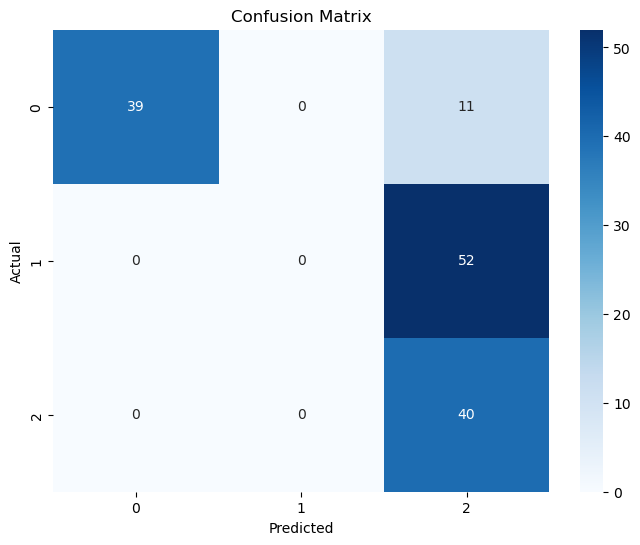

In [ ]:
# On suppose que votre matrice de confusion se nomme cm et votre modèle perceptron clf
# Si ce n'est pas le cas, adaptez le code ci dessous

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Nous allons maintenant utiliser un réseau multi-couche pour améliorer la classification. Pour cela une première étape est d'aller voir la documentation du MLP de sklearn :

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

Nous allons tester les différents hyperparamètres et mesurer leurs influences sur l'overfitting / underfitting.

Les hyper-paramètres seront déterminés grâce au validation set et le score final sera déterminé par le test set. Une fois le score calculé sur le test set, il ne faut ensuite plus modifier les hyperparamètres !

Note : sklearn est une excellente librairie, mais n'est pas la plus adaptée pour le deeplearning, nous l'utilisons ici car c'est ce que nous connaissons et car elle fait parfaitement l'affaire pour un simple MLP. Pour des architectures de deeplearning plus compliquées, Pytorch est maintenant la librairie python la plus populaire.

**Question 3** 

Le premier paramètre `hidden_layer_sizes` est le nombre et la taille des couches du réseau. 

`hidden_layer_sizes=[10,10]` donne par exemple un réseau avec deux couches de taille 10.

Un paramètre que vous aurez peut être envie de modifier est `max_iter`, sa valeur par défaut est 200, ce n'est pas énorme.

Les autres paramètres sont par exemple la fonction d'activation (ReLU par défaut) ou la méthode d'optimisation de descente de gradient (adam par défaut), vous pouvez expérimenter avec si vous le souhaitez.

Entrainez un MLP, pour le moment essayez un ou quelques paramètres "au hasard", nous les sélectionnerons rigoureusement par la suite.

In [ ]:
# TODO 
# Entrainez un perceptron multi couche et affichez les scores train / test

Score train : 0.647887323943662
Score test : 0.6666666666666666


**Question 4**

Entrainez plusieurs fois votre modèle à l'identique (relancez simplement la cellule précédente) et observez le score. 

Que remarquez vous ? Quelle est la raison ?

**Question 5** 

Peut-être obtenez vous déjà un bon score sur train et test, mais dans tous les cas nous avons oublié une étape qui peut avoir son importance, laquelle ?

Modifiez les données et mesurer le score en conservant votre modèle précédent.

Vous pouvez regarder :

`sklearn.preprocessing.StandardScaler`

In [ ]:
scaler = StandardScaler()
# TODO
# Standardisez vos données avec StandardScaler (allez voir la doc si besoin)

# TODO
# Entrainez votre perceptron multi couche avec les données standardisées et affichez les scores train / test

Score train : 1.0
Score test : 0.9444444444444444


**Question 6**

Testez à nouveau le perceptron, mais sur nos données transformées. Que concluez vous ?

In [ ]:
# TODO
# Entrainez votre perceptron avec les données standardisées et affichez les scores train / test

Score train : 1.0
Score test : 0.9444444444444444


### Nouveau dataset

Le dataset précédent était en réalité presque linéairement séparable, nous allons en étudier un pour lequel ce n'est pas le cas.

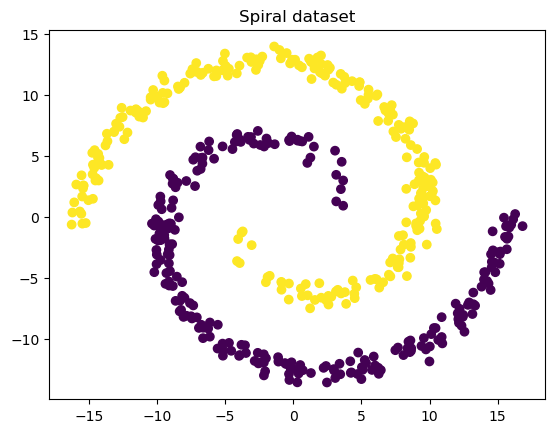

In [10]:


def make_spiral(n_samples=500, noise=0.5):
    n = n_samples // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi

    r_a = 2 * theta + np.pi
    data_a = np.c_[r_a * np.cos(theta), r_a * np.sin(theta)]

    r_b = -2 * theta - np.pi
    data_b = np.c_[r_b * np.cos(theta), r_b * np.sin(theta)]

    X = np.vstack([data_a, data_b])
    y = np.hstack([np.zeros(n), np.ones(n)])

    X += np.random.randn(*X.shape) * noise
    return X, y

X, y = make_spiral()

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Spiral dataset")
plt.show()

**Question 7**

Copiez-collez ce que vous avez fait pour le dataset du vin :

**a.** Split train/test

**b.** Perceptron

**c.** MLP

**d.** Standardisation

Cette fois ci, observe t on un gain réel à augmenter la compléxité du model ? (Justifiez)

In [ ]:
# TODO
# Observez la dimension de vos données
# Effectuez un split train / test
# Entrainez un perceptron et observez le score train / test



500 données de 2 dimensions.
Score train : 0.5375
Score test : 0.54


In [ ]:
# TODO
# Entrainez un perceptron multi couches et observez le score train / test

Score train : 0.9975
Score test : 1.0


In [ ]:
# TODO
# Standardisez vos données et réentrainez le MLP et perceptron, observez les scores train / test


Score train : 0.9925
Score test : 1.0
